# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace. 

<img src=https://i.imgur.com/36pCx5Q.jpg>

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server. 

In [29]:
# %pip install --upgrade plotly

### Import Statements

In [30]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Notebook Presentation

In [31]:
pd.options.display.float_format = '{:,.2f}'.format

### Read the Data

In [32]:
df_data = pd.read_csv('nobel_prize_data.csv')

Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd. 


# Data Exploration & Cleaning

**Challenge**: Preliminary data exploration. 
* What is the shape of `df_data`? How many rows and columns?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [33]:
"""What is the shape of df_data? How many rows and columns?"""
print(f'rows: {df_data.shape[0]}, cols:{df_data.shape[1]}')

"""What are the column names?"""
df_data.columns

rows: 962, cols:16


Index(['year', 'category', 'prize', 'motivation', 'prize_share',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'birth_country_current', 'sex', 'organization_name',
       'organization_city', 'organization_country', 'ISO'],
      dtype='object')

In [34]:
"""In which year was the nobel prize first awarded?"""
print(df_data.year.min())
"""Which year is the latest year included in the dataset?"""
print(df_data.year.max())

1901
2020


**Challange**: 
* Are there any duplicate values in the dataset?
* Are there NaN values in the dataset?
* Which columns tend to have NaN values?
* How many NaN values are there per column? 
* Why do these columns have NaN values?  

### Check for Duplicates

In [35]:
"""Are there any duplicate values in the dataset?"""
# print(df_data.duplicated(df_data))
print("There aren't any duplicates")

"""Are there NaN values in the dataset?"""
# print(df_data.dropna())
print(df_data.loc[958])
print('Yes there are NaN values in the dataset')

"""Which cols tend to have NaN values?"""
print('Cols that refer to more than one person or an organization have NaN values.')

There aren't any duplicates
year                                                                  2020
category                                                             Peace
prize                                           The Nobel Peace Prize 2020
motivation               “for its efforts to combat hunger, for its con...
prize_share                                                            1/1
laureate_type                                                 Organization
full_name                                       World Food Programme (WFP)
birth_date                                                             NaN
birth_city                                                             NaN
birth_country                                                          NaN
birth_country_current                                                  NaN
sex                                                                    NaN
organization_name                                                      N

In [36]:
"""How many NaN values are there per column?"""
print('9 per 16 cols')
"""Why do these cols have NaN values?"""
print("Because the data doesn't exist for those cols.")

9 per 16 cols
Because the data doesn't exist for those cols.


### Check for NaN Values

In [37]:
other_var = df_data.prize_share.str.replace('/','')
numerator = pd.to_numeric(other_var[0])
denominator = pd.to_numeric(other_var[1])







### Type Conversions

**Challenge**: 
* Convert the `birth_date` column to Pandas `Datetime` objects
* Add a Column called `share_pct` which has the laureates' share as a percentage in the form of a floating-point number.

#### Convert Year and Birth Date to Datetime

In [38]:
df_data['share_pct'] = numerator / denominator
df_data['share_pct']

0     1.00
1     1.00
2     1.00
3     1.00
4     1.00
      ... 
957   1.00
958   1.00
959   1.00
960   1.00
961   1.00
Name: share_pct, Length: 962, dtype: float64

#### Add a Column with the Prize Share as a Percentage

# Plotly Donut Chart: Percentage of Male vs. Female Laureates

**Challenge**: Create a [donut chart using plotly](https://plotly.com/python/pie-charts/) which shows how many prizes went to men compared to how many prizes went to women. What percentage of all the prizes went to women?

In [39]:
pie_data = df_data.value_counts('sex')

print(pie_data)
fig = px.pie(pie_data, values='count', names=pie_data.index, title='Awards won by sex')

fig.show()


sex
Male      876
Female     58
Name: count, dtype: int64


# Who were the first 3 Women to Win the Nobel Prize?

**Challenge**: 
* What are the names of the first 3 female Nobel laureates? 
* What did the win the prize for? 
* What do you see in their `birth_country`? Were they part of an organisation?

In [40]:
"""What are the names of the first 3 Nobel laureates?"""
women_data =df_data[df_data['sex'] == 'Female']

print(women_data[:3].full_name)

'What did they win the prize for?'
women_data[:3].prize

18                          Marie Curie, née Sklodowska
29    Baroness Bertha Sophie Felicita von Suttner, n...
51                        Selma Ottilia Lovisa Lagerlöf
Name: full_name, dtype: object


18       The Nobel Prize in Physics 1903
29            The Nobel Peace Prize 1905
51    The Nobel Prize in Literature 1909
Name: prize, dtype: object

In [41]:
"""What do you see in their burth_country? Were they part of an organisation?"""
print(women_data[:3].birth_country)

print('They were not part of any organisations.')

18             Russian Empire (Poland)
29    Austrian Empire (Czech Republic)
51                              Sweden
Name: birth_country, dtype: object
They were not part of any organisations.


# Find the Repeat Winners

**Challenge**: Did some people get a Nobel Prize more than once? If so, who were they? 

In [42]:
names = df_data.full_name
print(type(names))

names.is_unique

print('Some people did get more than one award')

<class 'pandas.core.series.Series'>
Some people did get more than one award


In [43]:
name_count_df = df_data.value_counts('full_name')
more_than_once = name_count_df[name_count_df > 1]
more_than_once

full_name
Comité international de la Croix Rouge (International Committee of the Red Cross)    3
Marie Curie, née Sklodowska                                                          2
Linus Carl Pauling                                                                   2
Frederick Sanger                                                                     2
John Bardeen                                                                         2
Office of the United Nations High Commissioner for Refugees (UNHCR)                  2
Name: count, dtype: int64


# Number of Prizes per Category

**Challenge**: 
* In how many categories are prizes awarded? 
* Create a plotly bar chart with the number of prizes awarded by category. 
* Use the color scale called `Aggrnyl` to colour the chart, but don't show a color axis.
* Which category has the most number of prizes awarded? 
* Which category has the fewest number of prizes awarded? 

In [44]:
"""In how many categories are prizes awarded?"""

df_data['category'].nunique()

6

In [45]:
category_count = df_data.groupby(by='category').count()



px.bar(data_frame=category_count, x=category_count.index, y=category_count.year,color=category_count.index, color_continuous_scale='Aggrnyl')

In [46]:
"""Which category has the most number of prizes awarded?"""
print('The Medicine category')

"""Which category has the fewest number of prizes awarded?"""
print('The Economics category')

The Medicine category
The Economics category


**Challenge**: 
* When was the first prize in the field of Economics awarded?
* Who did the prize go to?

In [47]:
print("""When was the first prize in the field of Economics awarded?""")
category_year = df_data[['category', 'year', 'prize']]
economics = category_year.loc[(category_year['category'] == 'Economics')]
first_year_index = economics.year.idxmin()
economics.year.min()

When was the first prize in the field of Economics awarded?


1969

In [48]:
print("""Who did the prize go to?""")

df_data.iloc[first_year_index]

df_data['full_name'][first_year_index]

Who did the prize go to?


'Jan Tinbergen'

# Male and Female Winners by Category

**Challenge**: Create a [plotly bar chart](https://plotly.com/python/bar-charts/) that shows the split between men and women by category. 
* Hover over the bar chart. How many prizes went to women in Literature compared to Physics?

<img src=https://i.imgur.com/od8TfOp.png width=650>

In [49]:
# category_sex = df_data[['category', 'sex']]
category_sex = df_data.groupby(by=['category','sex'],as_index=False).agg({'prize':pd.Series.count})
# cat_men_women = df_data.groupby(['category', 'sex'], 
                            #    as_index=False).agg({'prize': pd.Series.count})
category_sex



,category,sex,prize
0,Chemistry,Female,7
1,Chemistry,Male,179
2,Economics,Female,2
3,Economics,Male,84
4,Literature,Female,16
5,Literature,Male,101
6,Medicine,Female,12
7,Medicine,Male,210
8,Peace,Female,17
9,Peace,Male,90


In [50]:
px.bar(data_frame=category_sex, x='category', y='prize',color='sex', color_continuous_scale='Aggrnyl')

# px.bar(data_frame=category_sex, x=category_sex.index, y=category_count.year,color=category_count.index, color_continuous_scale='Aggrnyl')

# Number of Prizes Awarded Over Time

**Challenge**: Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually. 
* Count the number of prizes awarded every year. 
* Create a 5 year rolling average of the number of prizes (Hint: see previous lessons analysing Google Trends).
* Using Matplotlib superimpose the rolling average on a scatter plot.
* Show a tick mark on the x-axis for every 5 years from 1900 to 2020. (Hint: you'll need to use NumPy). 

<img src=https://i.imgur.com/4jqYuWC.png width=650>

* Use the [named colours](https://matplotlib.org/3.1.0/gallery/color/named_colors.html) to draw the data points in `dogerblue` while the rolling average is coloured in `crimson`. 

<img src=https://i.imgur.com/u3RlcJn.png width=350>

* Looking at the chart, did the first and second world wars have an impact on the number of prizes being given out? 
* What could be the reason for the trend in the chart?


In [51]:
"""Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually."""

prizes_by_year = df_data.groupby(by='year').agg({'prize':pd.Series.count})
print(prizes_by_year)
rolling_df = prizes_by_year.rolling(window=5).mean()
rolling_df


      prize
year       
1901      6
1902      7
1903      7
1904      6
1905      5
...     ...
2016     11
2017     12
2018     13
2019     14
2020     12

[117 rows x 1 columns]


,prize
year,
1901,NaN
1902,NaN
1903,NaN
1904,NaN
1905,6.20
...,...
2016,11.60
2017,12.00
2018,12.00


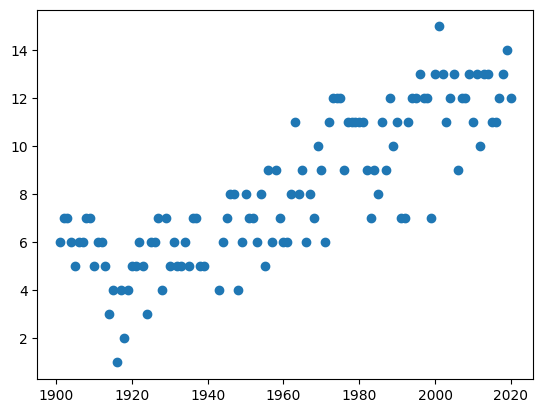

In [52]:
plt.scatter(prizes_by_year.index, prizes_by_year.prize)

In [53]:
year_arr = prizes_by_year.index.values

something = np.linspace(year_arr.min(), year_arr.max(), num=25)
print(something)

[1901.         1905.95833333 1910.91666667 1915.875      1920.83333333
 1925.79166667 1930.75       1935.70833333 1940.66666667 1945.625
 1950.58333333 1955.54166667 1960.5        1965.45833333 1970.41666667
 1975.375      1980.33333333 1985.29166667 1990.25       1995.20833333
 2000.16666667 2005.125      2010.08333333 2015.04166667 2020.        ]


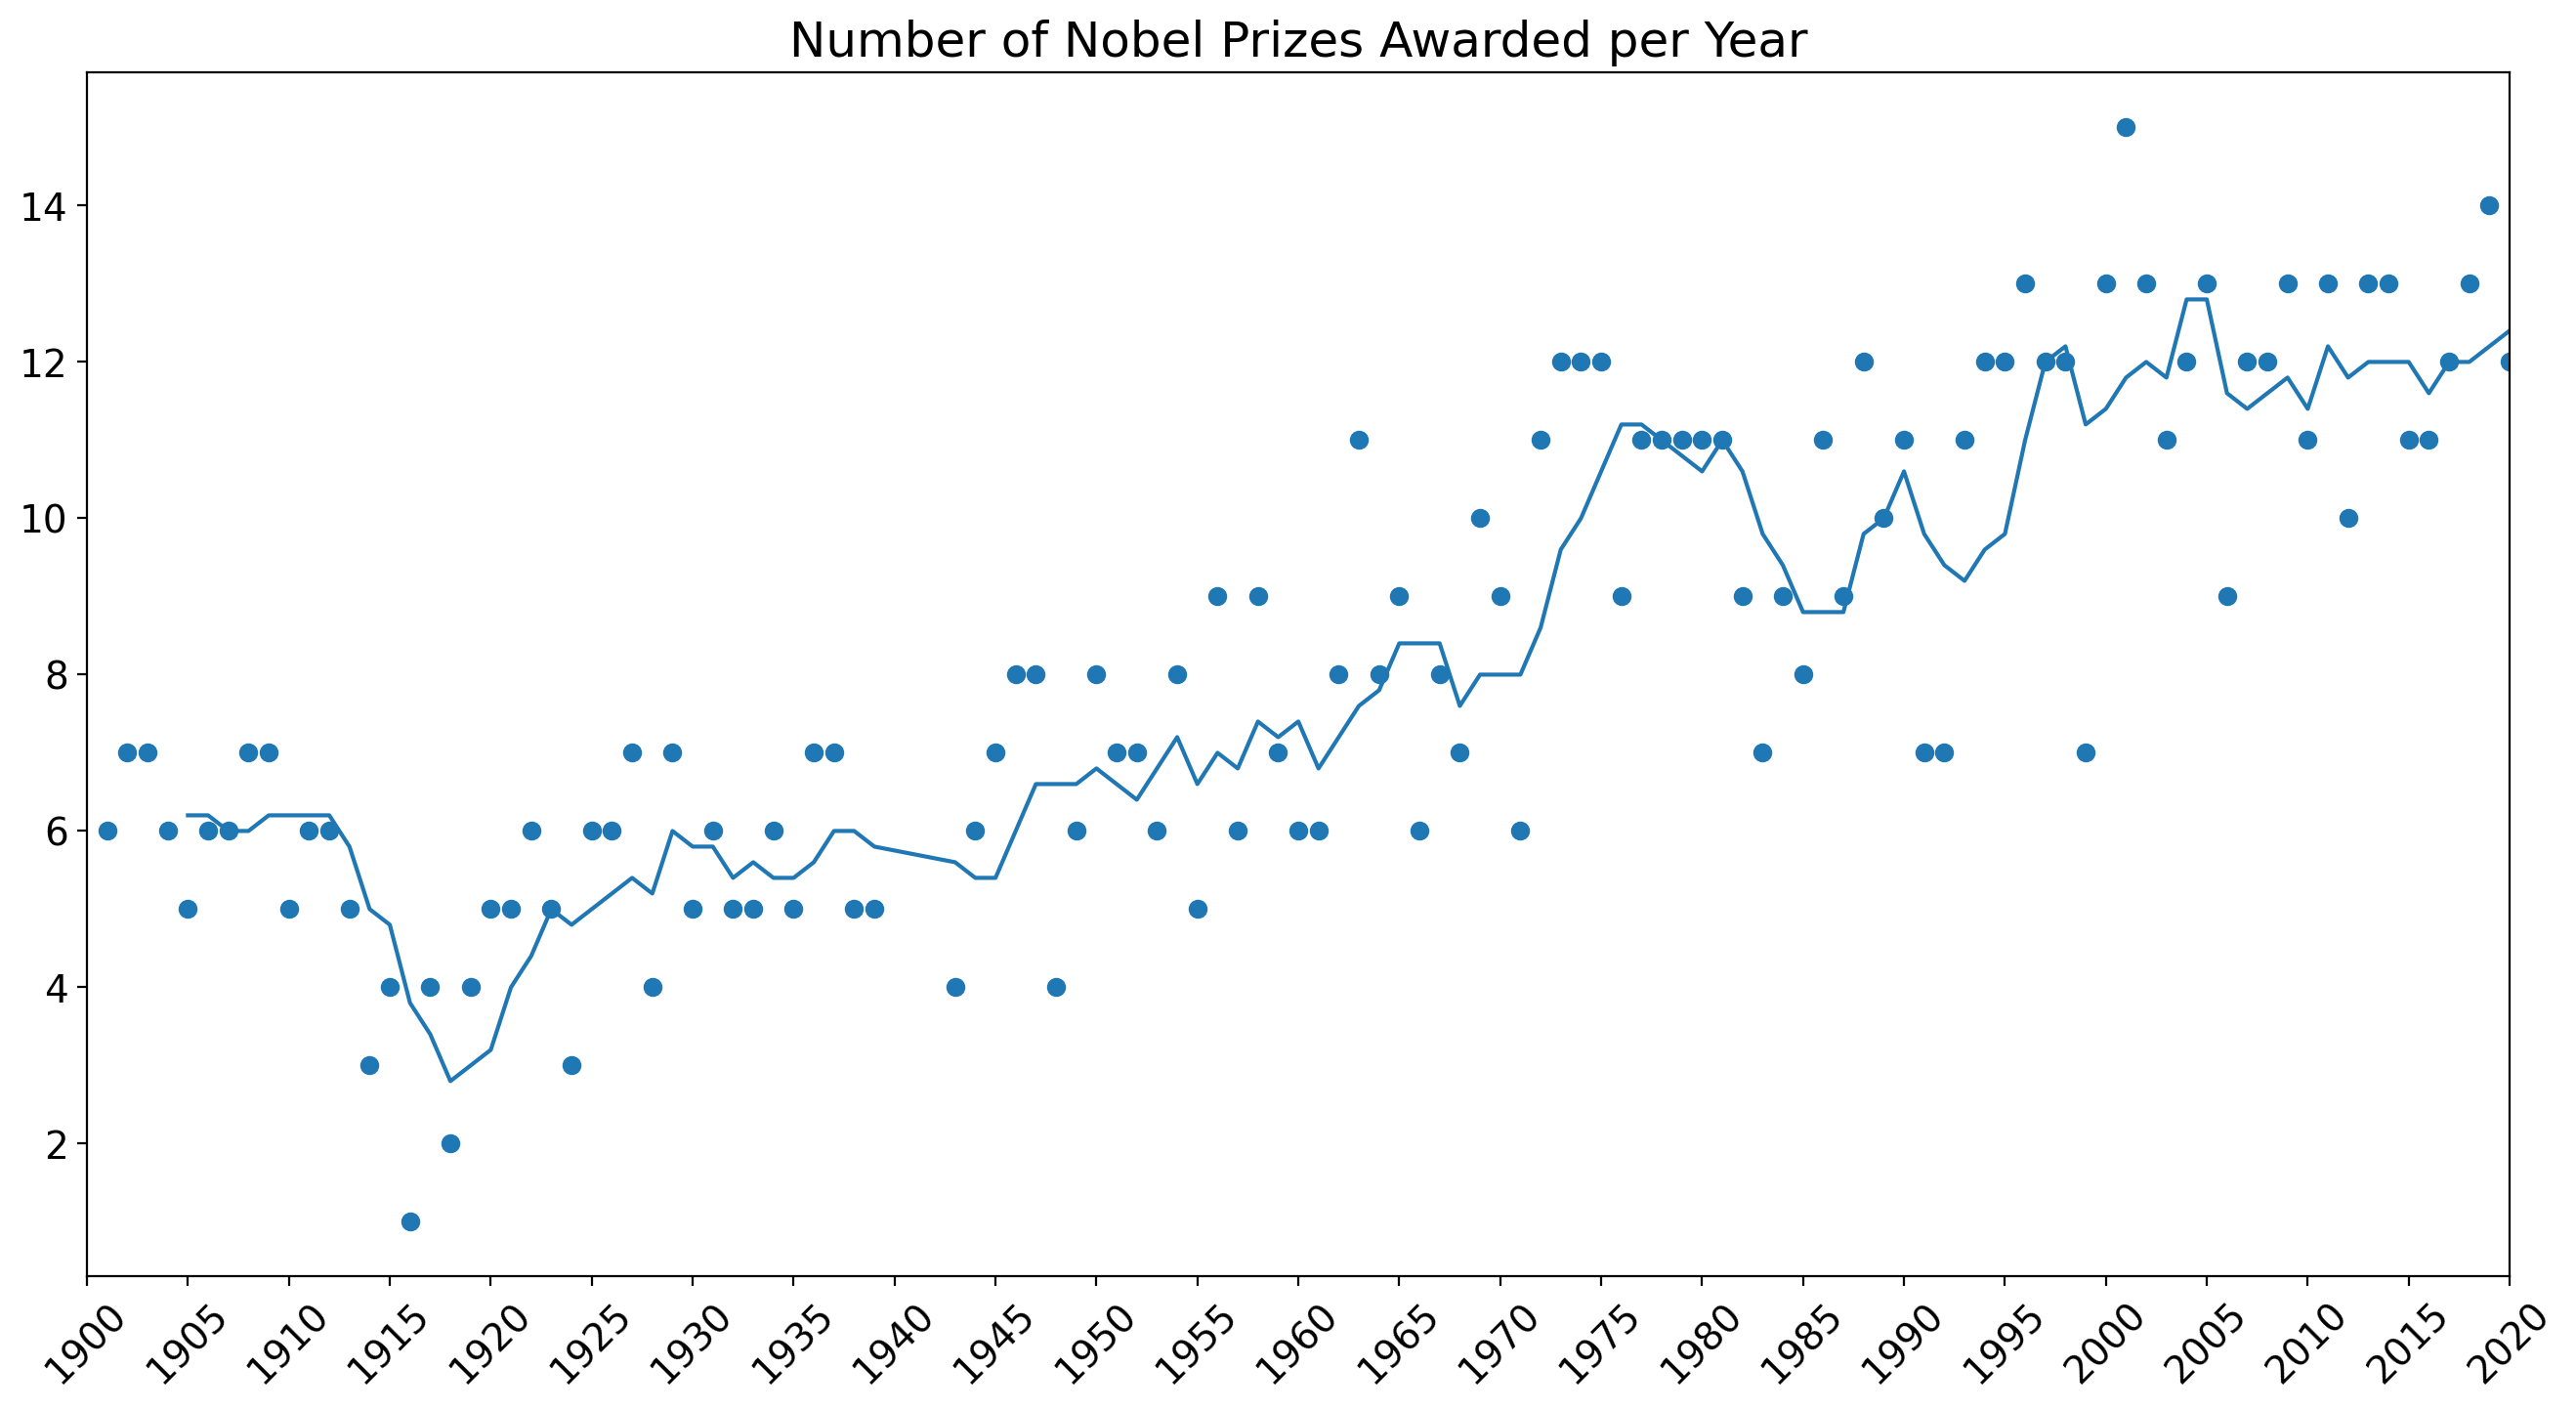

In [54]:
years = np.floor(something)
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks=np.arange(1900, 2021, step=5), 
           fontsize=14, 
           rotation=45)
 
ax = plt.gca() # get current axis
ax.set_xlim(1900, 2020)

ax.scatter(prizes_by_year.index, prizes_by_year.prize)

ax.plot(prizes_by_year.index, rolling_df.values)

# Are More Prizes Shared Than Before?

**Challenge**: Investigate if more prizes are shared than before. 

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.
* Copy-paste the cell from the chart you created above.
* Modify the code to add a secondary axis to your Matplotlib chart.
* Plot the rolling average of the prize share on this chart. 
* See if you can invert the secondary y-axis to make the relationship even more clear. 

In [55]:
"""Calculate the average prize share of the winners on a year by year basis"""
# l=df_data['prize_share'].values
# prize_share = list()
# for i in range(len(l)):
#     res = int(l[i][0]) / int(l[i][2])
#     prize_share.append(res)
# print(prize_share)
# df_data.drop(columns='prize_share')

# pd.Series(prize_share,name='prize_share')
# df_data['prize_share'] = prize_share

avg_prize_share = df_data.groupby(by=['year']).agg({'prize_share':pd.Series.mean})
avg_prize_share


TypeError: Could not convert string '1/11/11/11/21/21/1' to numeric

In [ ]:
five_yr_avg = avg_prize_share.rolling(5).mean()
print(five_yr_avg)


      prize_share
year             
1901          NaN
1902          NaN
1903          NaN
1904          NaN
1905         0.82
...           ...
2016         0.52
2017         0.50
2018         0.50
2019         0.50
2020         0.49

[117 rows x 1 columns]


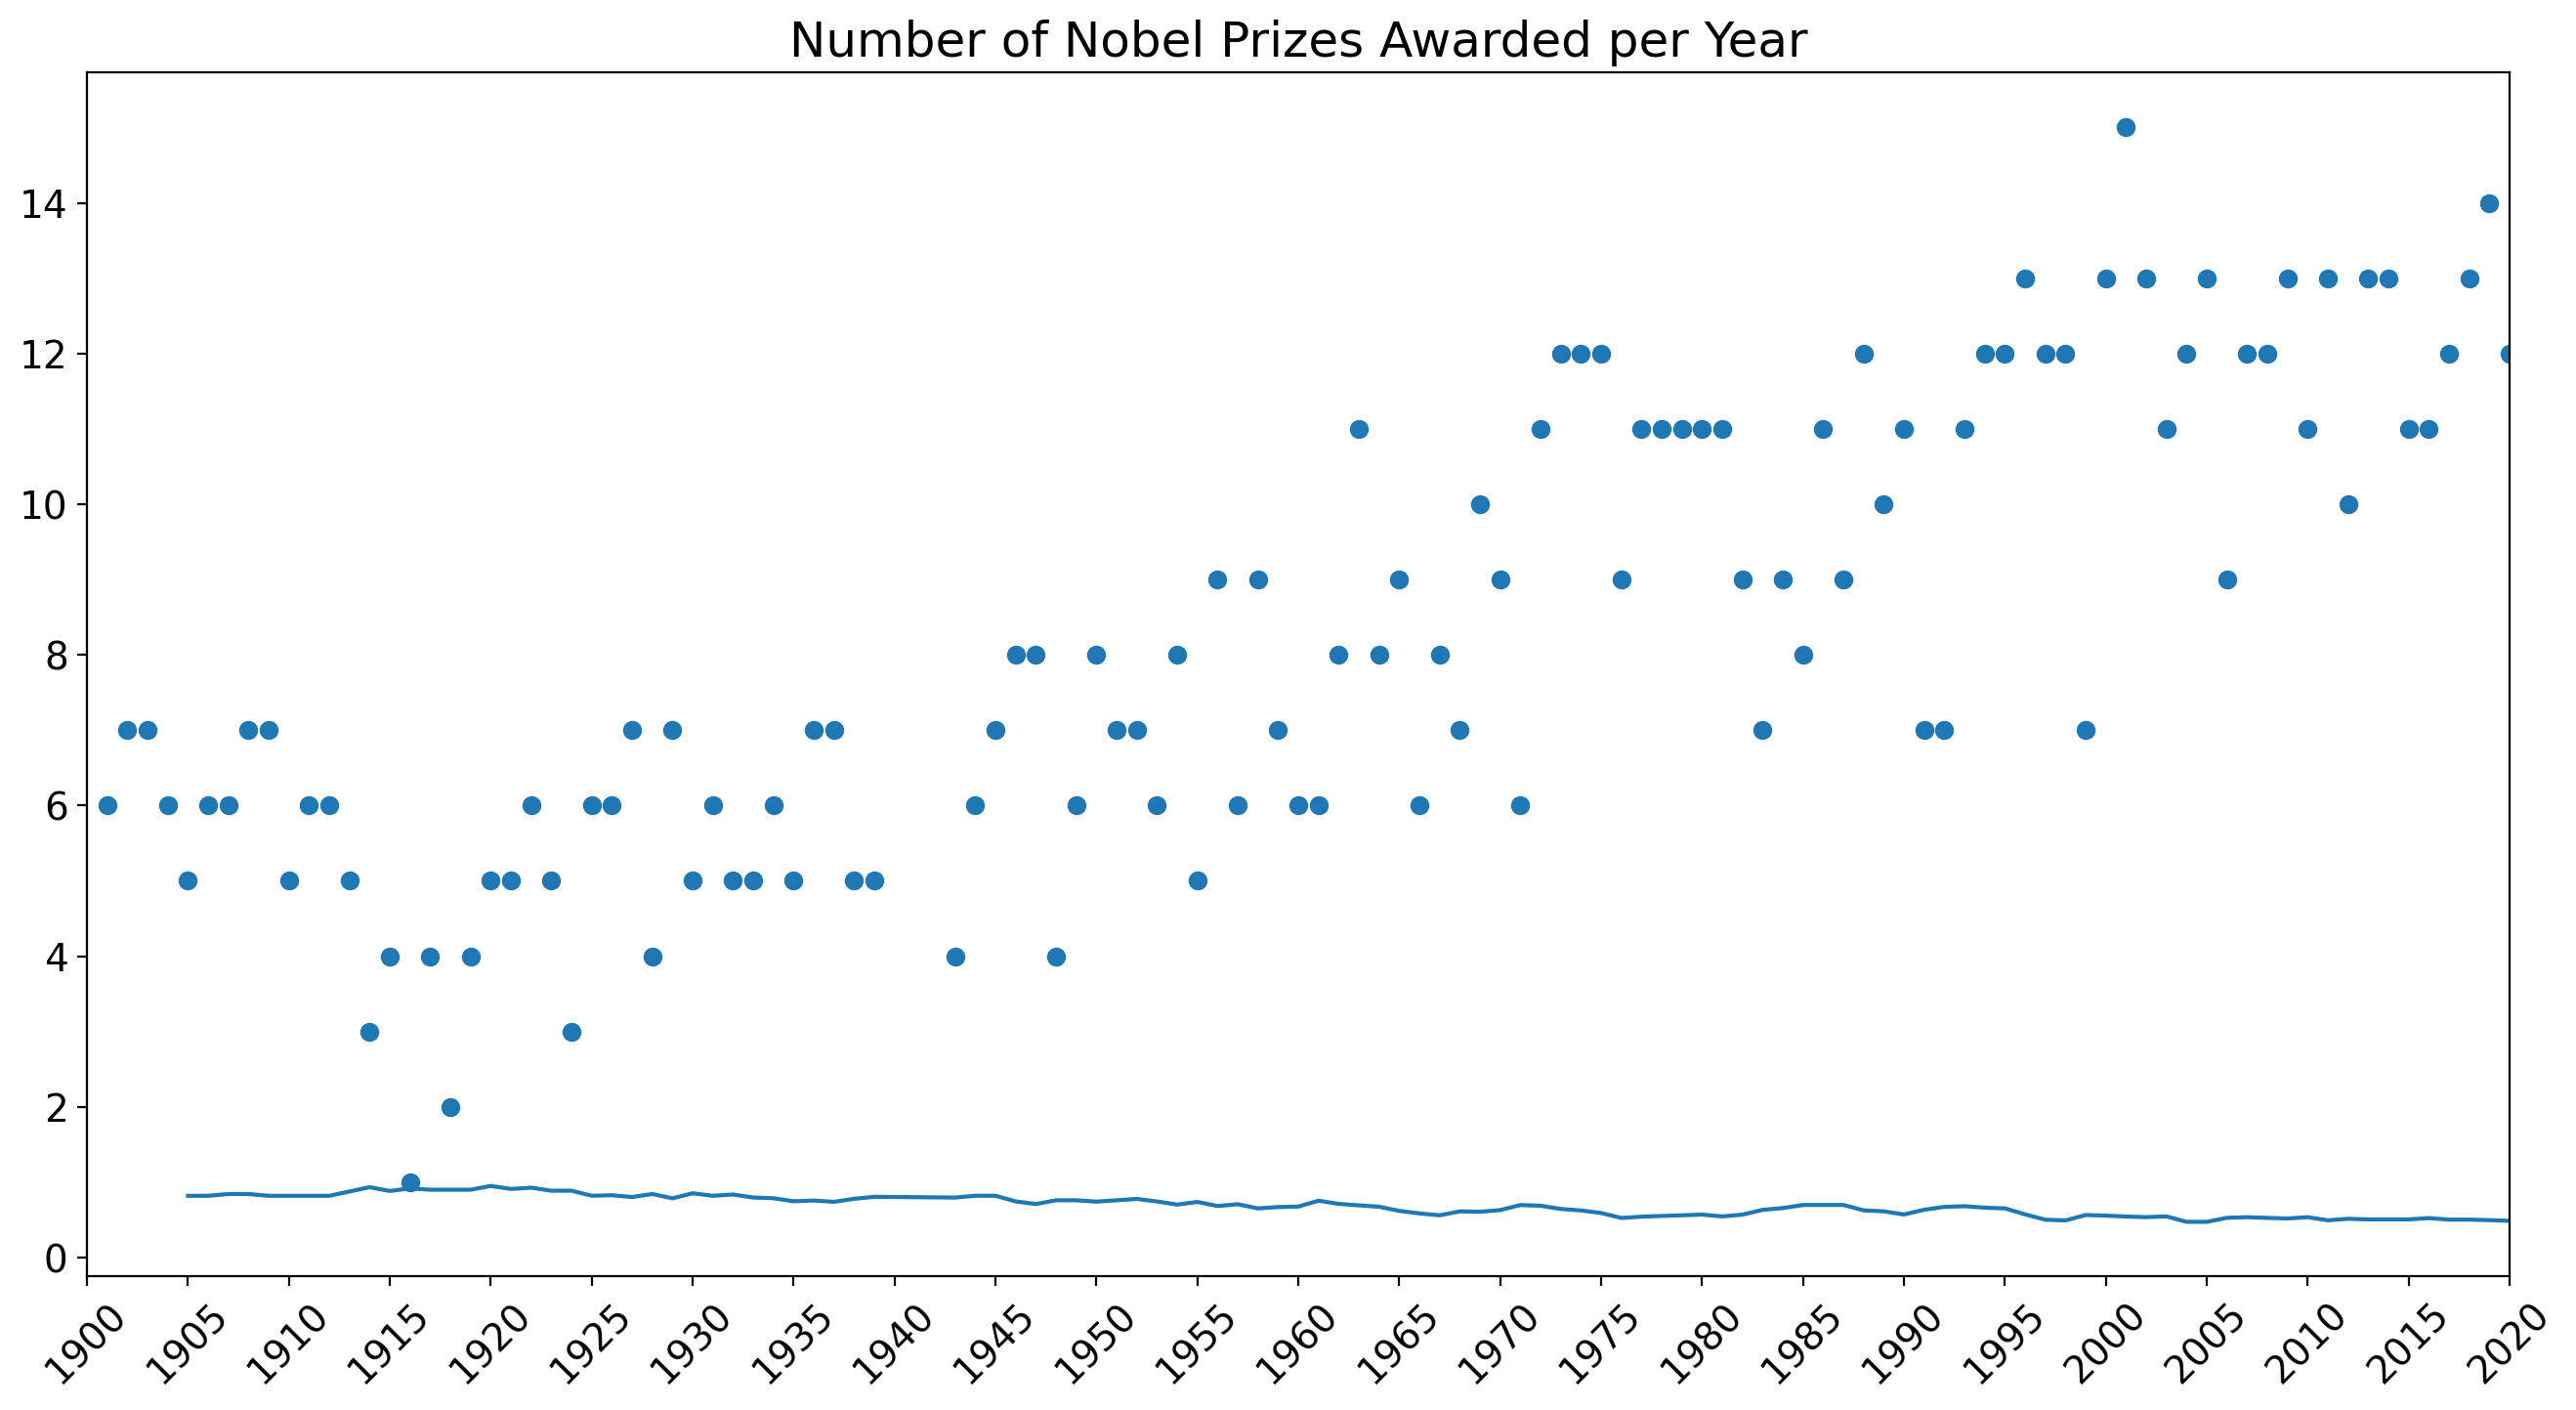

year
1901     6
1902     7
1903     7
1904     6
1905     5
        ..
2016    11
2017    12
2018    13
2019    14
2020    12
Name: prize, Length: 117, dtype: int64

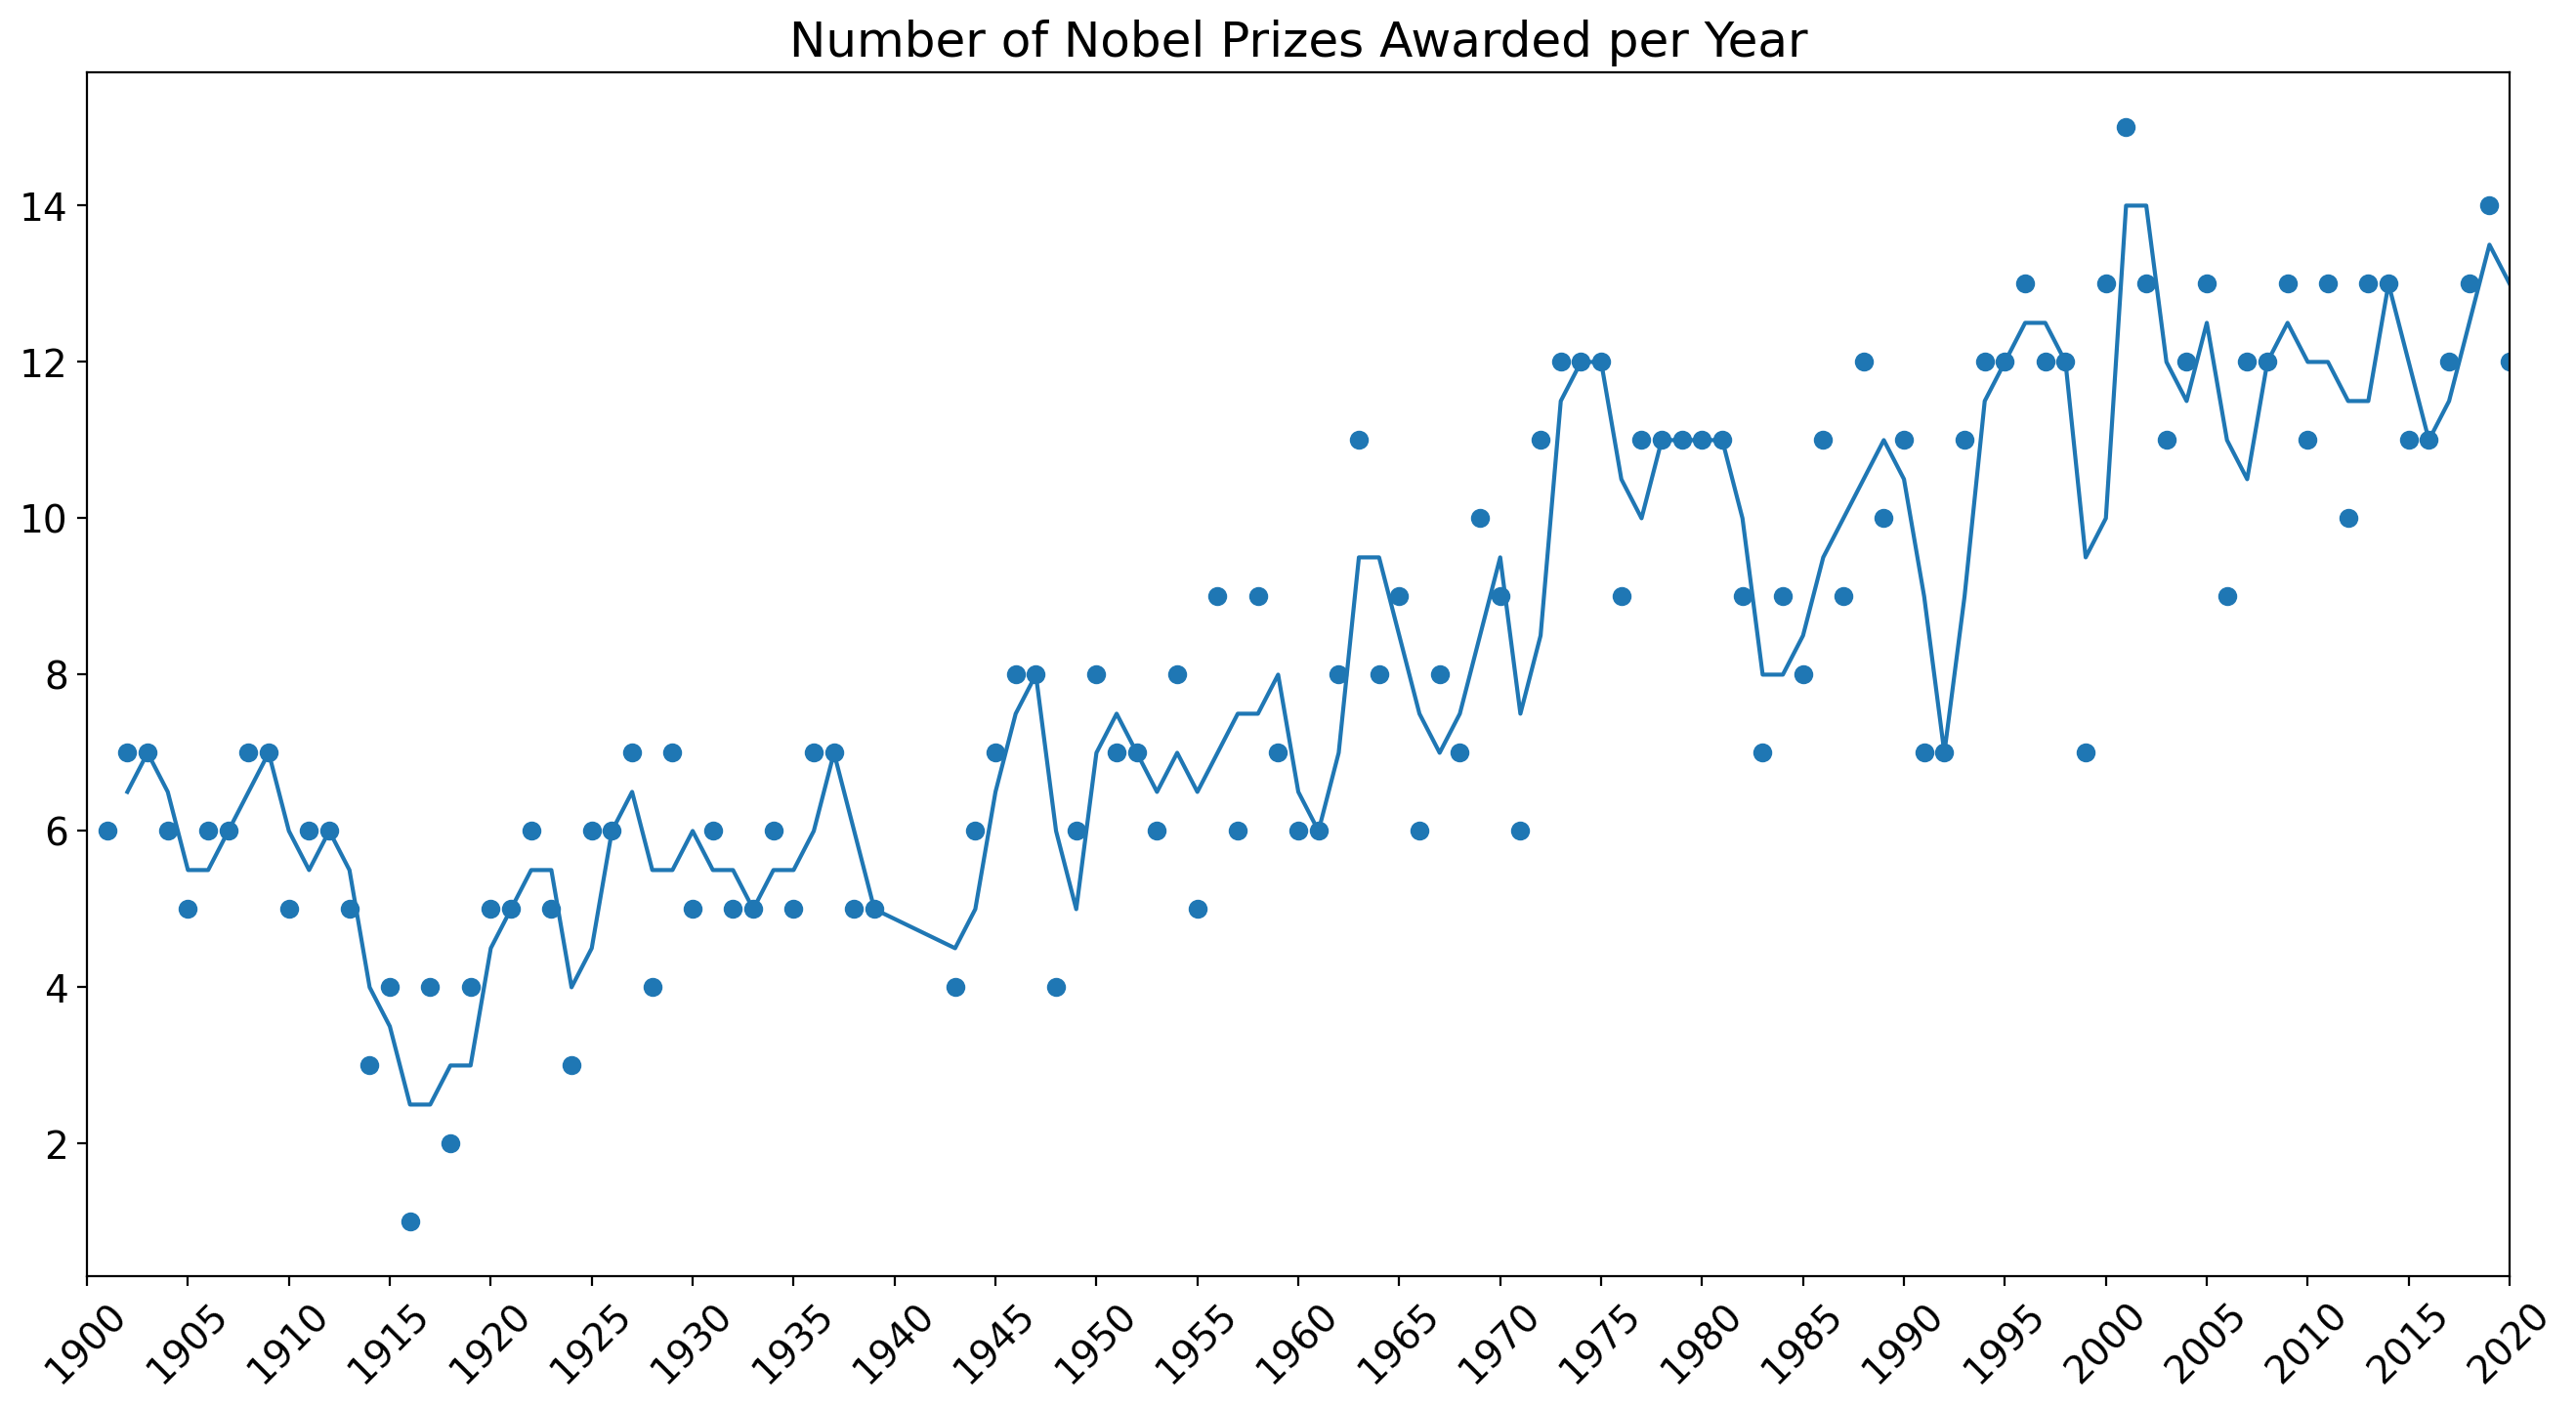

In [ ]:
years = np.floor(something)
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks=np.arange(1900, 2021, step=5), 
           fontsize=14, 
           rotation=45)
 
ax = plt.gca() # get current axis
ax.set_xlim(1900, 2020)

ax.scatter(prizes_by_year.index, prizes_by_year.prize)

ax.plot(prizes_by_year.index, rolling_df.values)

# The Countries with the Most Nobel Prizes

**Challenge**: 
* Create a Pandas DataFrame called `top20_countries` that has the two columns. The `prize` column should contain the total number of prizes won. 

<img src=https://i.imgur.com/6HM8rfB.png width=350>

* Is it best to use `birth_country`, `birth_country_current` or `organization_country`? 
* What are some potential problems when using `birth_country` or any of the others? Which column is the least problematic? 
* Then use plotly to create a horizontal bar chart showing the number of prizes won by each country. Here's what you're after:

<img src=https://i.imgur.com/agcJdRS.png width=750>

* What is the ranking for the top 20 countries in terms of the number of prizes?

In [ ]:
"""Create a pandas dataframe containing the country names and the amount of prizes they won"""

countries_df = df_data.groupby('birth_country_current').agg({'prize':pd.Series.count})
countries_df = countries_df.sort_values(by='prize', ascending=False)


,prize
birth_country_current,
United States of America,281
United Kingdom,105
Germany,84
France,57
Sweden,29
Japan,27
Poland,27
Russia,26
Canada,20


In [ ]:
print('Birth_country and Organization_country are inaccurate')

Birth_country and Organization_country are inaccurate


In [ ]:
print('birth_country_current is the least problematic of all 3 columns')

birth_country_current is the least problematic of all 3 columns


In [ ]:
px.bar(data_frame=countries_df, x='prize', y=countries_df.index, color='prize', color_continuous_scale='Inferno', orientation='h')

In [ ]:
print("""What is the ranking for the top 20 countries by prize count?""")
countries_df.head(20)

What is the ranking for the top 20 countries by prize count?


,prize
birth_country_current,
United States of America,281
United Kingdom,105
Germany,84
France,57
Sweden,29
Japan,27
Poland,27
Russia,26
Canada,20


# Use a Choropleth Map to Show the Number of Prizes Won by Country

* Create this choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/):

<img src=https://i.imgur.com/s4lqYZH.png>

* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 

Hint: You'll need to use a 3 letter country code for each country. 


In [ ]:
countries_df = df_data.groupby(by=['birth_country_current', 'ISO']).agg({'prize':pd.Series.count})
countries_df = countries_df.reset_index()
countries_df.sort_values('prize')


geomap = px.choropleth(data_frame=countries_df,locations='ISO',color='prize', hover_name='birth_country_current')

color_continuous_scale=px.colors.sequential.matter
 
geomap.update_layout(coloraxis_showscale=True)
 
geomap.show()



# In Which Categories are the Different Countries Winning Prizes? 

**Challenge**: See if you can divide up the plotly bar chart you created above to show the which categories made up the total number of prizes. Here's what you're aiming for:

<img src=https://i.imgur.com/iGaIKCL.png>

* In which category are Germany and Japan the weakest compared to the United States?
* In which category does Germany have more prizes than the UK?
* In which categories does France have more prizes than Germany?
* Which category makes up most of Australia's nobel prizes?
* Which category makes up half of the prizes in the Netherlands?
* Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?


The hard part is preparing the data for this chart! 


*Hint*: Take a two-step approach. The first step is grouping the data by country and category. Then you can create a DataFrame that looks something like this:

<img src=https://i.imgur.com/VKjzKa1.png width=450>


In [ ]:
"""In which category are Germany and Japan the weakest compared to the United States?"""
country_cat_prize = df_data.groupby(by=['birth_country_current', 'category']).aggregate({'prize':pd.Series.count})
total = df_data.groupby(by=['birth_country_current']).aggregate({'prize':pd.Series.count})

total = total.reset_index()
country_cat_prize = country_cat_prize.reset_index()

country_cat_prize = country_cat_prize.merge(total, on='birth_country_current', suffixes=('','_total'))

country_cat_prize = country_cat_prize.sort_values(by='prize_total', ascending=False).head(110)

px.bar(data_frame=country_cat_prize, x='prize', y='birth_country_current', orientation='h', color='category',color_continuous_scale='Inferno')




In [ ]:
"""In which category does Germany have more prizes than the UK?"""
print('Literature')

Literature


In [ ]:
"""In which categories does France have more prizes than Germany?"""
print('Literature, Peace')

In [ ]:
"""Which category makes up most of Australia's nobel prizes?"""
print("Medicine")

In [ ]:
"""Which category makes up half of the prizes in the Netherlands?"""
print("Physics")

In [ ]:
"""Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?"""
france = country_cat_prize[country_cat_prize.birth_country_current == 'France']
print(france)
print("No the US doesn't have more economic prizes then all of France. THey do in Physics and Medicine though.")

   birth_country_current    category  prize  prize_total
65                France   Chemistry     10           57
70                France     Physics     10           57
69                France       Peace     10           57
68                France    Medicine     12           57
66                France   Economics      4           57
67                France  Literature     11           57



### Number of Prizes Won by Each Country Over Time

* When did the United States eclipse every other country in terms of the number of prizes won? 
* Which country or countries were leading previously?
* Calculate the cumulative number of prizes won by each country in every year. Again, use the `birth_country_current` of the winner to calculate this. 
* Create a [plotly line chart](https://plotly.com/python/line-charts/) where each country is a coloured line. 

In [ ]:
"""When did the United States eclipse every other country in terms of the number of prizes won?"""
prizes_over_time = df_data.groupby(by=['year', 'birth_country_current']).agg({'prize':pd.Series.count})
prizes_over_time = prizes_over_time.rename(mapper={'prize':'prizes_this_year'}, axis=1)
prizes_over_time = prizes_over_time.reset_index()
# print(prizes_over_time)
total = df_data.groupby(by=['birth_country_current']).aggregate({'prize':pd.Series.count})
total = total.rename(mapper={'prize':'total_prizes_all_time'}, axis=1)

# print(total)

total_prizes = prizes_over_time.sum()
total_prizes = total_prizes.prizes_this_year

prizes_over_time = prizes_over_time.merge(total['total_prizes_all_time'], on='birth_country_current')

prizes_over_time['cumulative_sum'] = prizes_over_time.groupby(by='birth_country_current')['prizes_this_year'].cumsum()
prizes_over_time['percent_control'] = prizes_over_time['cumulative_sum'] / total_prizes
# prizes_over_time.sort_values('percent_control', ascending=False).tail()
prizes_over_time.sort_values(['percent_control', 'year'], ascending=False).head(60)




# prizes_over_time['remaining'] = (prizes_over_time['total_prizes_all_time'] - prizes_over_time['prizes_this_year'])
# prizes_over_time

px.scatter(prizes_over_time,x='year', y='percent_control', color='birth_country_current', trendline='lowess')

print('1955')


In [ ]:
"""Which country or states were leading previoiusly?"""
print("Germany")

In [ ]:
"""Calculate the cumulative number of prizes won by each country every year."""
prizes_over_time[['birth_country_current','cumulative_sum']]

,birth_country_current,cumulative_sum
0,France,2
1,Germany,1
2,Netherlands,1
3,Poland,1
4,Switzerland,1
...,...,...
622,United States of America,274
623,France,57
624,Germany,84
625,United Kingdom,105


In [ ]:
px.line(prizes_over_time,x='year', y='percent_control', color='birth_country_current')

# What are the Top Research Organisations?

**Challenge**: Create a bar chart showing the organisations affiliated with the Nobel laureates. It should looks something like this:

<img src=https://i.imgur.com/zZihj2p.png width=600>

* Which organisations make up the top 20?
* How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?

In [ ]:
"""What are the top 20 research organizations?"""
org_df = df_data.groupby(by=['organization_name']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False)
org_df = org_df.rename(mapper={'prize':'num_of_prizes'}, axis=1).head(20)
org_df

,num_of_prizes
organization_name,
University of California,40
Harvard University,29
Stanford University,23
Massachusetts Institute of Technology (MIT),21
University of Chicago,20
University of Cambridge,18
California Institute of Technology (Caltech),17
Columbia University,17
Princeton University,15


In [ ]:
px.bar(data_frame=org_df, x='num_of_prizes', y=org_df.index, color='num_of_prizes', color_continuous_scale='Inferno', )

In [ ]:
"""How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?"""
affilates_df = df_data.groupby(by=['organization_name', 'full_name']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False).dropna()
affilates_df = affilates_df.reset_index()

"""Ways to achieve this dataframe"""
# affilates_df[(affilates_df.organization_name == 'Harvard University') | (affilates_df.organization_name == 'University of Chicago')]
#filtered_df = affilates_df.query("organization_name == 'Harvard University' or organization_name == 'University of Chicago'")
# affilates_df[affilates_df['organization_name'].isin(['Harvard University', 'University of Chicago'])]

filtered_df = affilates_df.query("organization_name == 'Harvard University' or organization_name == 'University of Chicago'")

filtered_df = filtered_df.groupby('organization_name').agg({'full_name':pd.Series.nunique})
filtered_df = filtered_df.rename(mapper={'full_name': 'num of prize winners'}, axis=1)
filtered_df





# stuff = affilates_df.query('organization_name == `University of Chicago` or `Harvard University`')
# stuff


*Ways to achieve this dataframe:

```python 
affilates_df[(affilates_df.organization_name == 'Harvard University') | (affilates_df.organization_name == 'University of Chicago')]

filtered_df = affilates_df.query("organization_name == 'Harvard University' or organization_name == 'University of Chicago'")

affilates_df[affilates_df['organization_name'].isin(['Harvard University', 'University of Chicago'])]```


# Which Cities Make the Most Discoveries? 

Where do major discoveries take place?  

**Challenge**: 
* Create another plotly bar chart graphing the top 20 organisation cities of the research institutions associated with a Nobel laureate. 
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

In [ ]:
"""Where is the number one hotspot for discoveries in the world?"""

affilates_df = df_data.groupby(by=['organization_city']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False).dropna()
data_set = affilates_df.head(20)
data_set = data_set.reset_index()
print('Cambridge')



Cambridge


In [ ]:
px.bar(data_frame=data_set, x='organization_city', y='prize', color='organization_city', color_continuous_scale='Inferno')

# Where are Nobel Laureates Born? Chart the Laureate Birth Cities 

**Challenge**: 
* Create a plotly bar chart graphing the top 20 birth cities of Nobel laureates. 
* Use a named colour scale called `Plasma` for the chart.
* What percentage of the United States prizes came from Nobel laureates born in New York? 
* How many Nobel laureates were born in London, Paris and Vienna? 
* Out of the top 5 cities, how many are in the United States?


In [ ]:
print("""What percentage of the United States prizes are from Nobel laureates born in New York?""")
birth_city_df = df_data.groupby(by=['birth_city','birth_country', 'full_name']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False).dropna()
birth_city_df = birth_city_df.reset_index()

us_df = birth_city_df.query("birth_country == 'United States of America'")
total_prize = us_df.sum().prize
ny_count= us_df[us_df['birth_city'] == 'New York, NY'].prize.values[0]
print(f'percentage: {ny_count/total_prize}\n')

print("""How many Nobel laureates were born in London, Paris and Vienna?""")
lpv_df = birth_city_df[birth_city_df['birth_city'].isin(['London', 'Paris', 'Vienna'])]
lpv_df = lpv_df.groupby('birth_city').agg({'full_name':pd.Series.count})
lpv_df = lpv_df.rename(mapper={'full_name':'# of laureates'}, axis=1)

print(f'#london:{lpv_df.at['London', '# of laureates']}\n #vienna:{lpv_df.at['Vienna', '# of laureates']}\n #paris:{lpv_df.at['Paris', '# of laureates']}\n')

print("""Out of the top 5 cities, how many are in the United States?""")

top_cities_df = df_data.groupby(by=['birth_city','birth_country']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False).dropna()
top_5_in_us = top_cities_df.head(5).query("birth_country == 'United States of America'")

count = top_5_in_us.count().prize
print(count)






What percentage of the United States prizes are from Nobel laureates born in New York?
percentage: 0.0035587188612099642

How many Nobel laureates were born in London, Paris and Vienna?
#london:19
 #vienna:14
 #paris:26

Out of the top 5 cities, how many are in the United States?
2


In [ ]:
top_cities_df = top_cities_df.sort_values(by='prize', ascending=False).head(20)
top_cities_df = top_cities_df.reset_index()
px.bar(top_cities_df, x='birth_city', y='prize', color='birth_city', color_continuous_scale='Plasma')

In [ ]:
print(lpv_df)

            # of laureates
birth_city                
London                  19
Paris                   26
Vienna                  14


*One way to access value in column with index:

```python 
print(f'#london:{lpv_df.at['London', '# of laureates']}\n #vienna:{lpv_df.at['Vienna', '# of laureates']}\n #paris:{lpv_df.at['Paris', '# of laureates']}') ```


# Plotly Sunburst Chart: Combine Country, City, and Organisation

**Challenge**: 

* Create a DataFrame that groups the number of prizes by organisation. 
* Then use the [plotly documentation to create a sunburst chart](https://plotly.com/python/sunburst-charts/)
* Click around in your chart, what do you notice about Germany and France? 


Here's what you're aiming for:

<img src=https://i.imgur.com/cemX4m5.png width=300>



In [ ]:
"""Create a Data frame that groups the number of prizes by organization"""

org_name_df = df_data.groupby(by=['organization_name', 'birth_country_current', 'birth_city']).agg({'prize':pd.Series.count}).sort_values('prize', ascending=False).dropna().head(80)
org_name_df = org_name_df.reset_index()
org_name_df

,organization_name,birth_country_current,birth_city,prize
0,Harvard University,United States of America,"New York, NY",9
1,California Institute of Technology (Caltech),United States of America,"New York, NY",4
2,National Institutes of Health,United States of America,"New York, NY",3
3,Rockefeller University,United States of America,"New York, NY",3
4,Institut Pasteur,France,Paris,3
...,...,...,...,...
75,University of California,United States of America,"Yukon, FL",1
76,University of California,United States of America,"Cleveland, OH",1
77,University of California,United States of America,"Canton, SD",1
78,University College London,United States of America,"New York, NY",1


In [ ]:
"""Create sunburst chart"""


sb_graph = px.sunburst(data_frame=org_name_df, path=['birth_country_current','birth_city','organization_name'], color='birth_country_current', color_continuous_scale='Inferno')
sb_graph.show()

In [ ]:
"""Germany and France?"""
print('They both contain the University of California?')

# Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

**Challenge**: Calculate the age of the laureate in the year of the ceremony and add this as a column called `winning_age` to the `df_data` DataFrame. Hint: you can use [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.html) to help you. 



In [62]:
bd_df = df_data[['full_name', 'birth_date', 'year']].drop_duplicates('full_name')

bd_df['birth_date'] = pd.to_datetime(bd_df['birth_date'], yearfirst=True, exact=False)
# bd_df['year'] = pd.to_datetime(bd_df['year'], yearfirst=True, exact=False)

print("""converted to string to avoid the annoying epoch and year starting at 1970""")
print("""Have to do this when year value is less that 1970!!!""")
bd_df['year'] = pd.to_datetime(bd_df['year'].astype('str'), format='%Y')

bd_df['winning_age'] = (bd_df['year'].dt.year - bd_df['birth_date'].dt.year)
bd_df.dropna(axis=0, how='any', inplace=True)
print(bd_df.sort_values('winning_age'))



converted to string to avoid the annoying epoch and year starting at 1970
Have to do this when year value is less that 1970!!!
                  full_name birth_date       year  winning_age
885        Malala Yousafzai 1997-01-01 2014-01-01        17.00
932             Nadia Murad 1993-01-01 2018-01-01        25.00
85   William Lawrence Bragg 1890-01-01 1915-01-01        25.00
188     Carl David Anderson 1905-01-01 1936-01-01        31.00
305    Tsung-Dao (T.D.) Lee 1926-01-01 1957-01-01        31.00
..                      ...        ...        ...          ...
856        Lloyd S. Shapley 1923-01-01 2012-01-01        89.00
961           Roger Penrose 1931-01-01 2020-01-01        89.00
794          Leonid Hurwicz 1917-01-01 2007-01-01        90.00
933           Arthur Ashkin 1922-01-01 2018-01-01        96.00
937         John Goodenough 1922-01-01 2019-01-01        97.00

[930 rows x 4 columns]


### Who were the oldest and youngest winners?

**Challenge**: 
* What are the names of the youngest and oldest Nobel laureate? 
* What did they win the prize for?
* What is the average age of a winner?
* 75% of laureates are younger than what age when they receive the prize?
* Use Seaborn to [create histogram](https://seaborn.pydata.org/generated/seaborn.histplot.html) to visualise the distribution of laureate age at the time of winning. Experiment with the number of `bins` to see how the visualisation changes.

In [63]:
"""What are the names of the youngest and oldest Nobel laureate?""" 
print(bd_df.query("winning_age == winning_age.min()").full_name)
print('')
"""* What did they win the prize for?"""
print(df_data.at[(bd_df.query("winning_age == winning_age.min()").index[0]), 'motivation'])
print('')
"""* What is the average age of a winner?"""
print(bd_df['winning_age'].mean())
print('')
"""* 75% of laureates are younger than what age when they receive the prize?"""
print(bd_df['winning_age'].quantile(0.75))


885    Malala Yousafzai
Name: full_name, dtype: object

"for their struggle against the suppression of children and young people and for the right of all children to education"

59.958064516129035

69.0


<Axes: xlabel='year', ylabel='winning_age'>

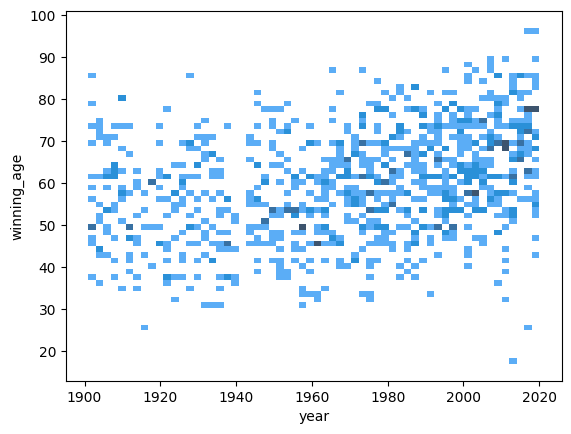

In [64]:
sns.histplot(bd_df, x='year', y='winning_age',bins=60 )

### Descriptive Statistics for the Laureate Age at Time of Award

* Calculate the descriptive statistics for the age at the time of the award. 
* Then visualise the distribution in the form of a histogram using [Seaborn's .histplot() function](https://seaborn.pydata.org/generated/seaborn.histplot.html).
* Experiment with the `bin` size. Try 10, 20, 30, and 50.  

count   930.00
mean     59.96
std      12.63
min      17.00
25%      51.00
50%      60.00
75%      69.00
max      97.00
Name: winning_age, dtype: float64


<Axes: xlabel='winning_age', ylabel='Count'>

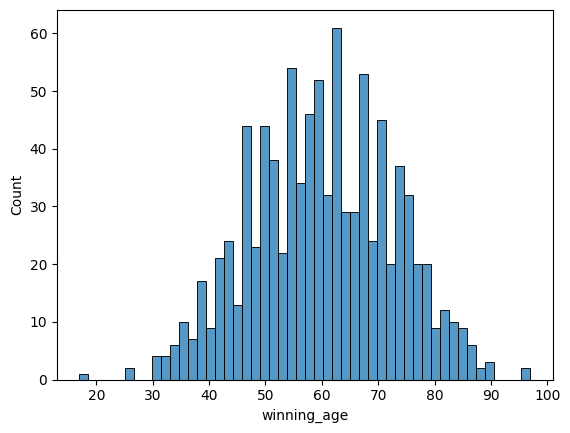

In [65]:
print(bd_df['winning_age'].describe())
sns.histplot(bd_df, x='winning_age',bins=50)

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?

**Challenge**

* Use Seaborn to [create a .regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html?highlight=regplot#seaborn.regplot) with a trendline.
* Set the `lowess` parameter to `True` to show a moving average of the linear fit.
* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?


<Axes: xlabel='year', ylabel='winning_age'>

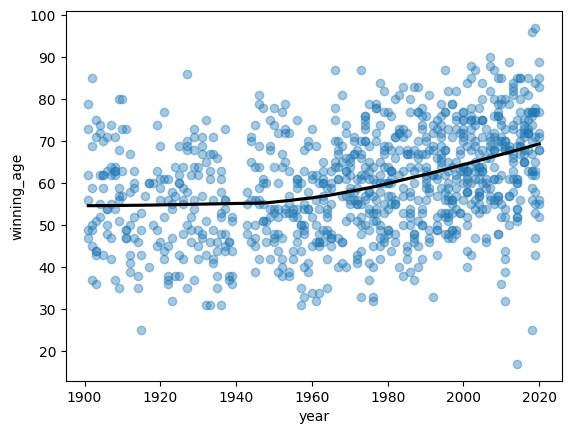

In [66]:
sns.regplot(bd_df, x=bd_df.year.dt.year.astype(str).astype(float), y='winning_age', lowess=True, scatter_kws = {'alpha': 0.4},
                line_kws={'color': 'black'})

In [67]:
print("""* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?""")
print('55')

print("""* According to the best fit line, what age would it predict for a Nobel laureate in 2020?""")
print('65')

* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
55
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?
65


### Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category? 

* Use Seaborn's [`.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot) to show how the mean, quartiles, max, and minimum values vary across categories. Which category has the longest "whiskers"? 
* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

                        full_name    category
0    Jacobus Henricus van 't Hoff   Chemistry
1                 Sully Prudhomme  Literature
2          Emil Adolf von Behring    Medicine
3                  Frédéric Passy       Peace
4               Jean Henry Dunant       Peace
..                            ...         ...
957              Michael Houghton    Medicine
958    World Food Programme (WFP)       Peace
959                   Andrea Ghez     Physics
960               Reinhard Genzel     Physics
961                 Roger Penrose     Physics

[955 rows x 2 columns]
            winning_age
category               
Chemistry         58.88
Economics         66.97
Literature        64.79
Medicine          58.58
Peace             60.90
Physics           56.40


<Axes: xlabel='category', ylabel='winning_age'>

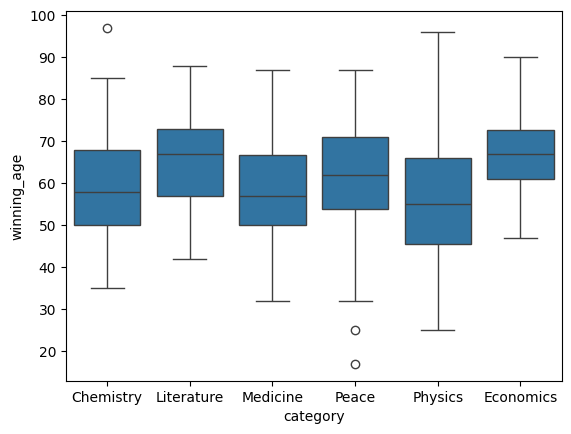

In [95]:

df_data['birth_date'] = pd.to_datetime(df_data['birth_date'].astype(str), format='%Y', exact=False)

other= df_data[['full_name', 'category']].dropna(subset='full_name', how='any').drop_duplicates(subset='full_name')
# bd_df = bd_df.merge(other, on='full_name')
print(other)

# bd_df.reset_index(inplace=True)

desc = bd_df[['category', 'winning_age']]
# print(desc)

cat_df = bd_df.groupby('category').agg({"winning_age":pd.Series.mean})
print(cat_df)

sns.boxplot(desc, x='category', y='winning_age')




In [ ]:
print("""In which category are the average winners the oldest?""")
print('physics')

print("""In which category are the average winners the youngest?""")
print('economics')

**Challenge**
* Now use Seaborn's [`.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot) and the `row` parameter to create 6 separate charts for each prize category. Again set `lowess` to `True`.
* What are the winning age trends in each category? 
* Which category has the age trending up and which category has the age trending down? 
* Is this `.lmplot()` telling a different story from the `.boxplot()`?
* Create another chart with Seaborn. This time use `.lmplot()` to put all 6 categories on the same chart using the `hue` parameter. 


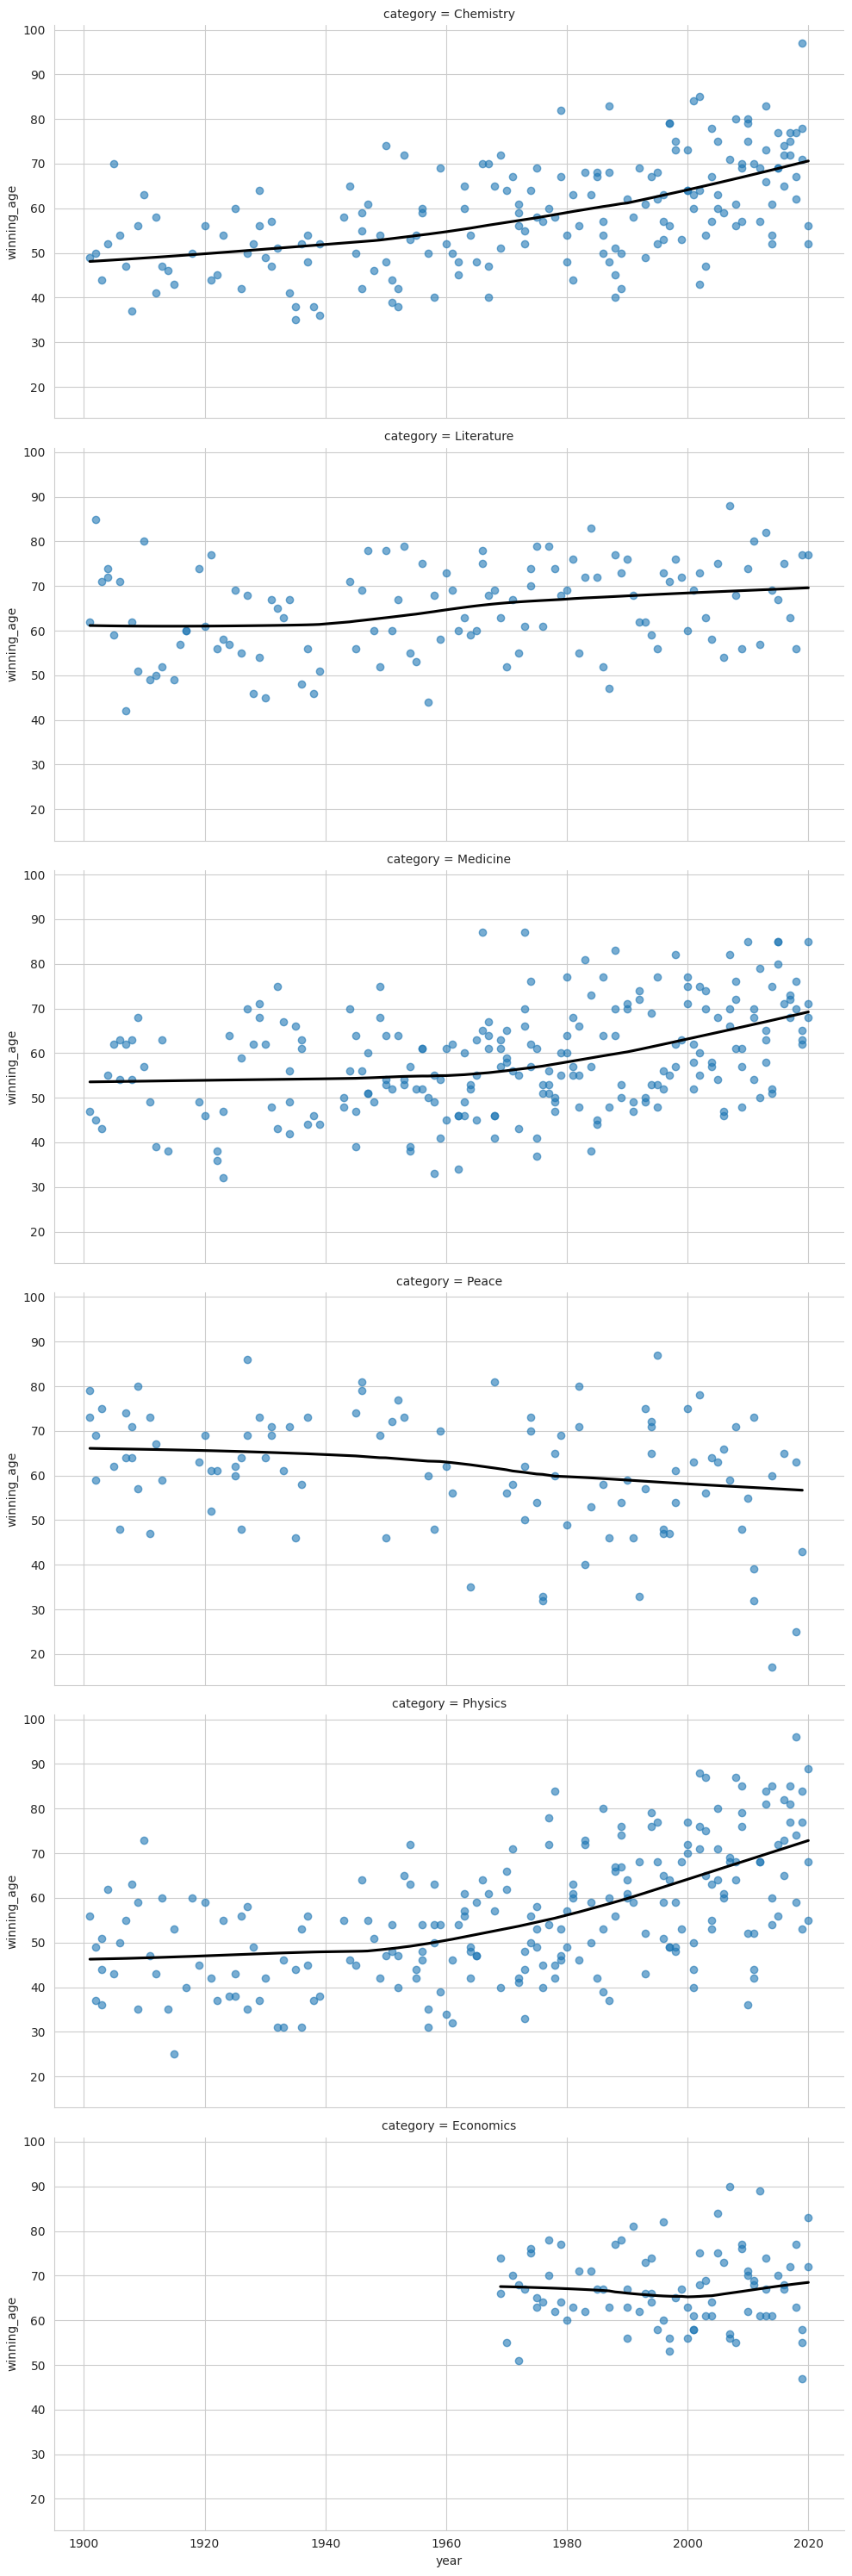

In [146]:
data = bd_df.drop(axis=1, columns=['category_x', 'category_y'])
data = data.drop(axis=1, columns=['level_0','index'])
chemistry = data.query("category == 'Chemistry'")

data['year'] = data['year'].dt.year.astype(int).dropna()
data['winning_age'] = data['winning_age'].astype(int).dropna()

with sns.axes_style('whitegrid'):
    sns.lmplot(data=data,
               x='year', 
               y='winning_age',
               row = 'category',
               lowess=True, 
               aspect=2,
               scatter_kws = {'alpha': 0.6},
               line_kws = {'color': 'black'},)

plt.show()

